In [1]:
import sys
sys.path.append("..")

from src.clonality import run_clonality_analysis
from src.dataset_loader import load_dataset

import scanpy as sc
import matplotlib
from matplotlib import rcParams

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, dpi_save=300, color_map='Reds', facecolor='white')
matplotlib.rcParams.update({'figure.figsize': (4, 4)})

adata_d4 = load_dataset("hemo_larry_d4")
adata_d7 = load_dataset("hemo_larry_d7")
adata_d4_endo = load_dataset("hemo_larry_d4_endo")
adata_d12 = load_dataset("hemo_larry_d12")

### barcode qc

In [3]:
from src.clonality import generate_full_clone_report

res = generate_full_clone_report(
    adata_d12,
    output_dir="../figure/hemo-larry-d12",
    dataset_name="hemo-larry-d12"
)

Clonality Report: hemo-larry-d12
--------------------------------------------------
Total clones: 1838
Gini coefficient: 0.6936
Shannon entropy: 8.8469
Normalized entropy: 0.8158
Simpson diversity: 0.9907
Expansion index: 0.8896


### Day 4

In [10]:
import cospar as cs
import pandas as pd
import scipy.io as sio
import numpy as np
import os

In [11]:
cs.logging.print_version()

# Set the messaging level. At a given value, a running function will
# print information at or below its level.
cs.settings.verbosity = 2  # range: 0 (error),1 (warning),2 (info),3 (hint).

# Plot setting. If you want to control a particular plot,
# just change the setting here, and run that plotting function.
cs.settings.set_figure_params(
    format="png", figsize=[4, 3.5], dpi=75, fontsize=14, pointsize=3
)

Running cospar 0.3.4 (python 3.11.10) on 2025-06-19 08:08.


ERROR: XMLRPC request failed [code: -32500]
RuntimeError: PyPI no longer supports 'pip search' (or XML-RPC search). Please use https://pypi.org/search (via a browser) instead. See https://warehouse.pypa.io/api-reference/xml-rpc.html#deprecated-methods for more information.


In [5]:
adata = sc.read_h5ad('/mnt/yiming/nfs_share/hema_wave/hemo-larry-d4-rna-clone-v2.h5ad')

In [4]:
adata_raw = sc.read_10x_h5('/mnt/yiming/nfs_share/larry/Larry-D4/outs/filtered_feature_bc_matrix.h5')

reading /mnt/yiming/nfs_share/larry/Larry-D4/outs/filtered_feature_bc_matrix.h5
 (0:00:01)


/mnt/yiming/nfs_share/anaconda3/envs/scvi-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/mnt/yiming/nfs_share/anaconda3/envs/scvi-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [6]:
adata_raw = adata_raw[adata_raw.obs.index.isin(adata.obs.index)]
adata_raw.obs['CellType_man'] = adata.obs['CellType_man']
adata_raw.obsm['X_emb'] = adata.obsm['X_umap']
adata_raw.uns['data_des'] = 'larry-d4'

df_X_clone = adata.obs[['larry_clone']]
cell_ids = [f'cell_{i+1}' for i in range(len(df_X_clone))]

df_X_clone['Cell_ID'] = cell_ids
df_X_clone.rename(columns={'larry_clone': 'Clone_ID'}, inplace=True)

adata_raw.obs_names = cell_ids
cs.pp.get_X_clone(adata_raw, df_X_clone["Cell_ID"], df_X_clone["Clone_ID"])

/tmp/ipykernel_1389645/1454432131.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_raw.obs['CellType_man'] = adata.obs['CellType_man']
/mnt/yiming/nfs_share/anaconda3/envs/scvi-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/mnt/yiming/nfs_share/anaconda3/envs/scvi-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/tmp/ipykernel_1389645/1454432131.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-

reorder clones


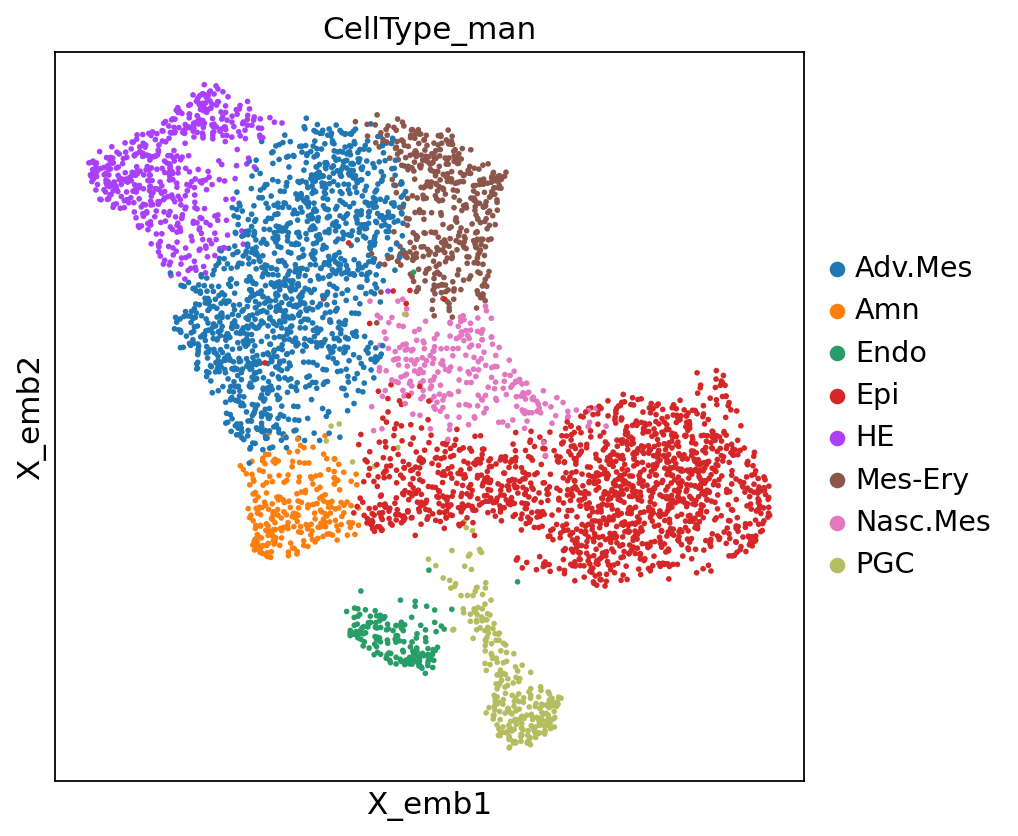

In [7]:
cs.pl.embedding(adata_raw, color="CellType_man")

normalizing by total count per cell
    finished (0:00:00): normalized adata.X and added
    'n_counts', counts per cell before normalization (adata.obs)
Finding highly variable genes...


/mnt/yiming/nfs_share/anaconda3/envs/scvi-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


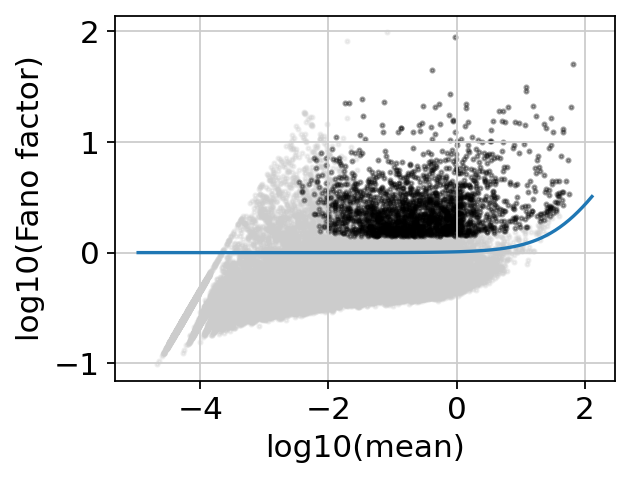

Keeping 1995 genes


In [8]:
cs.pp.get_highly_variable_genes(
    adata_raw,
    normalized_counts_per_cell=10000,
    min_counts=3,
    min_cells=3,
    min_gene_vscore_pctl=90,
)

In [9]:
adata_raw.var_names_make_unique()

cs.pp.get_X_pca(adata_raw, n_pca_comp=40)
cs.pp.get_X_emb(adata_raw, n_neighbors=20, umap_min_dist=0.3)

/mnt/yiming/nfs_share/anaconda3/envs/scvi-env/lib/python3.9/site-packages/sklearn/utils/validation.py:727: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  warnings.warn(


computing neighbors
    using 'X_pca' with n_pcs = 40


/mnt/yiming/nfs_share/anaconda3/envs/scvi-env/lib/python3.9/site-packages/sklearn/utils/validation.py:727: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  warnings.warn(
/mnt/yiming/nfs_share/anaconda3/envs/scvi-env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:06)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:05)


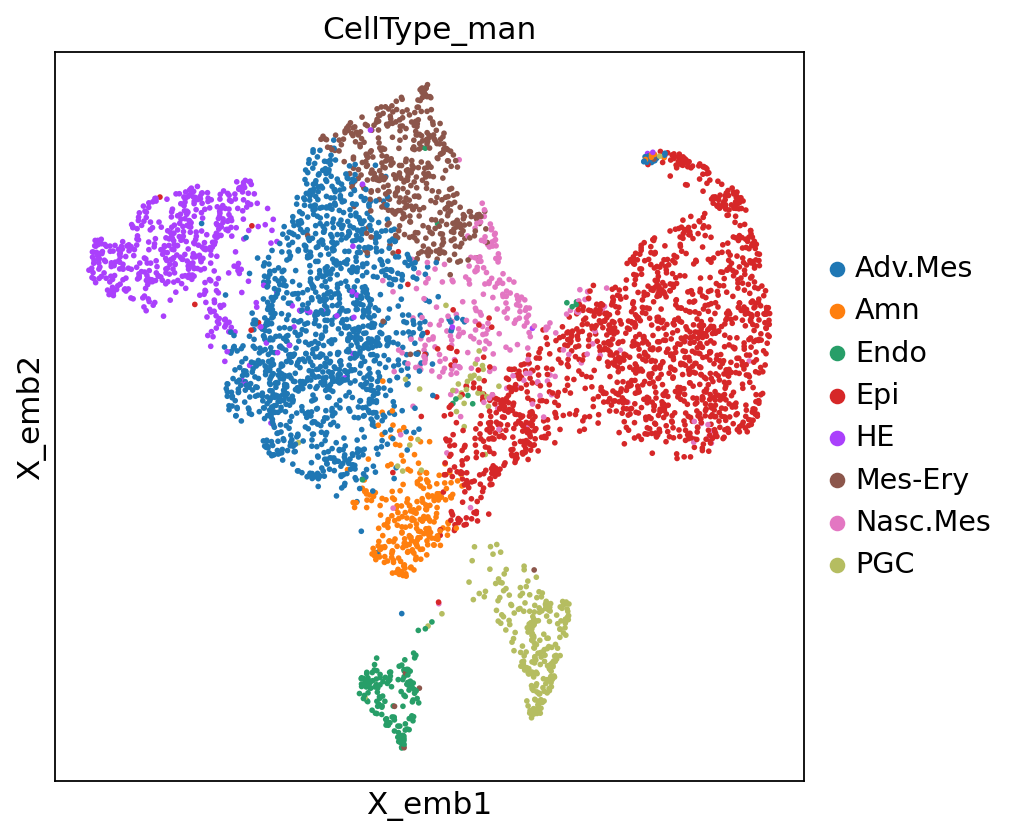

In [10]:
cs.pl.embedding(adata_raw, color="CellType_man")

In [11]:
adata_raw.obs['time_info'] = '4'
adata_raw.obs['state_info'] = adata_raw.obs['CellType_man'].copy()

In [ ]:
selected_times = None
selected_fates = adata_raw.obs['CellType_man'].cat.categories
celltype_names = adata_raw.obs['CellType_man'].cat.categories
cs.pl.barcode_heatmap(
    adata_raw,
    selected_times=selected_times,
    selected_fates=selected_fates,
    color_bar=True,
    rename_fates=celltype_names,
    log_transform=False,
    binarize=True,
)
ax = plt.gca()
ax.grid(False)

In [33]:
cs.settings.set_figure_params(
    format="png", figsize=[4, 4], dpi=300, fontsize=15, pointsize=3
)

In [ ]:
cs.tl.fate_coupling(
    adata_raw, selected_fates=selected_fates, source="X_clone"
)  # compute the fate coupling
cs.pl.fate_coupling(adata_raw, source="X_clone")  # actually plot the coupling
ax = plt.gca()
ax.grid(False)

In [32]:
cs.tl.fate_hierarchy(
    adata_raw, selected_fates=selected_fates, source="X_clone"
)  # compute the fate hierarchy
cs.pl.fate_hierarchy(adata_raw, source="X_clone")  # actually plot the hierarchy

normalize by X_clone
each selected cluster has a unique time point. Normalize per time point
normalize by X_clone
each selected cluster has a unique time point. Normalize per time point
normalize by X_clone
each selected cluster has a unique time point. Normalize per time point
normalize by X_clone
each selected cluster has a unique time point. Normalize per time point
normalize by X_clone
each selected cluster has a unique time point. Normalize per time point
normalize by X_clone
each selected cluster has a unique time point. Normalize per time point
Results saved as dictionary at adata.uns['fate_hierarchy_X_clone']

         /-Nasc.Mes
      /-|
     |   \-Amn
     |
     |            /-HE
   /-|         /-|
  |  |      /-|   \-Adv.Mes
  |  |     |  |
  |  |   /-|   \-Mes-Ery
--|  |  |  |
  |   \-|   \-PGC
  |     |
  |      \-Epi
  |
   \-Endo


ANALYSIS: How many clones of different sources go to Mes-Ery?
Target cell type: Mes-Ery (303 clones)
Metric: (shared clones between source and B) / (source clones)

RESULTS (sorted by percentage, highest first):
    Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
CDX2+ Hypo             55             12                       21.82                 12/55
       Epi           1143             28                        2.45               28/1143

INTERPRETATION:
Higher percentage means more of that source's clones also contain Mes-Ery
Example: 50% means half of that source's clones also go to Mes-Ery

TOP FINDING: CDX2+ Hypo has highest sharing with Mes-Ery
  → 21.8% of CDX2+ Hypo clones contain Mes-Ery
  → That's 12 out of 55 clones


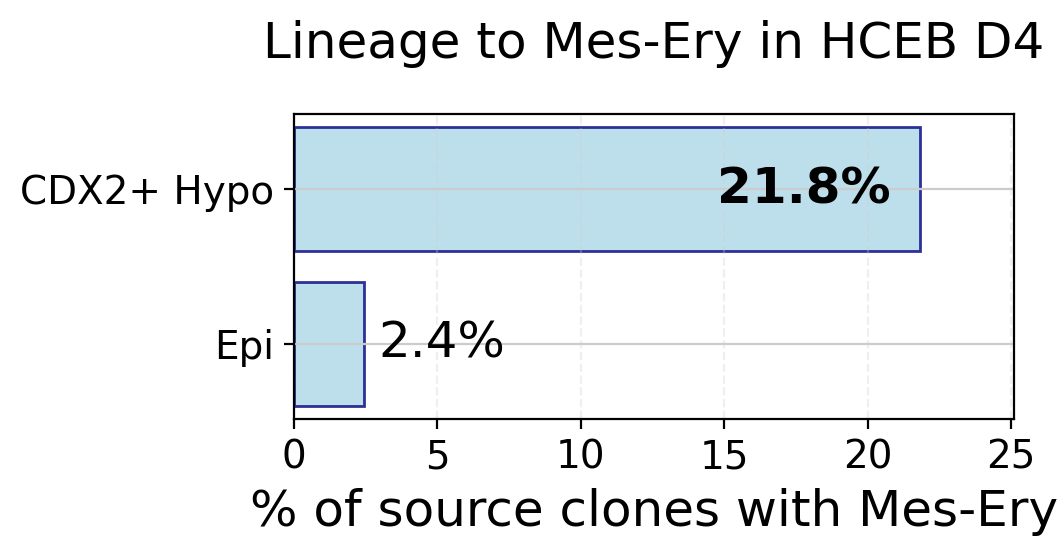

,Source,Target,Source Clones,Target Clones,Shared Clones,Clones with Both,Percentage (shared/source),Ratio (shared/source),Shared Clone IDs,Clones with Both IDs
0,CDX2+ Hypo,Mes-Ery,55,303,12,12,21.818182,12/55,"[clone_375, clone_1998, clone_151, clone_251, ...","[clone_375, clone_1998, clone_151, clone_251, ..."
1,Epi,Mes-Ery,1143,303,28,28,2.449694,28/1143,"[clone_595, clone_1066, clone_660, clone_480, ...","[clone_595, clone_1066, clone_660, clone_480, ..."


In [3]:
from src.clonality import quick_clone_check, analyze_multiple_to_B, visualize_sources_to_B, plot_shared_clones_AB_only
visualize_sources_to_B(adata_d4, 'CellType_man_v2', 
                       ['CDX2+ Hypo', 'Epi'], 
                       'Mes-Ery', 
                       figsize=(5.5, 3), 
                      fig_title='Lineage to Mes-Ery in HCEB D4')

ANALYSIS: How many clones of different sources go to Mes-Ery?
Target cell type: Mes-Ery (303 clones)
Metric: (shared clones between source and B) / (source clones)

RESULTS (sorted by percentage, highest first):
Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
  Endo            117             31                       26.50                31/117
   Epi           1143             28                        2.45               28/1143

INTERPRETATION:
Higher percentage means more of that source's clones also contain Mes-Ery
Example: 50% means half of that source's clones also go to Mes-Ery

TOP FINDING: Endo has highest sharing with Mes-Ery
  → 26.5% of Endo clones contain Mes-Ery
  → That's 31 out of 117 clones


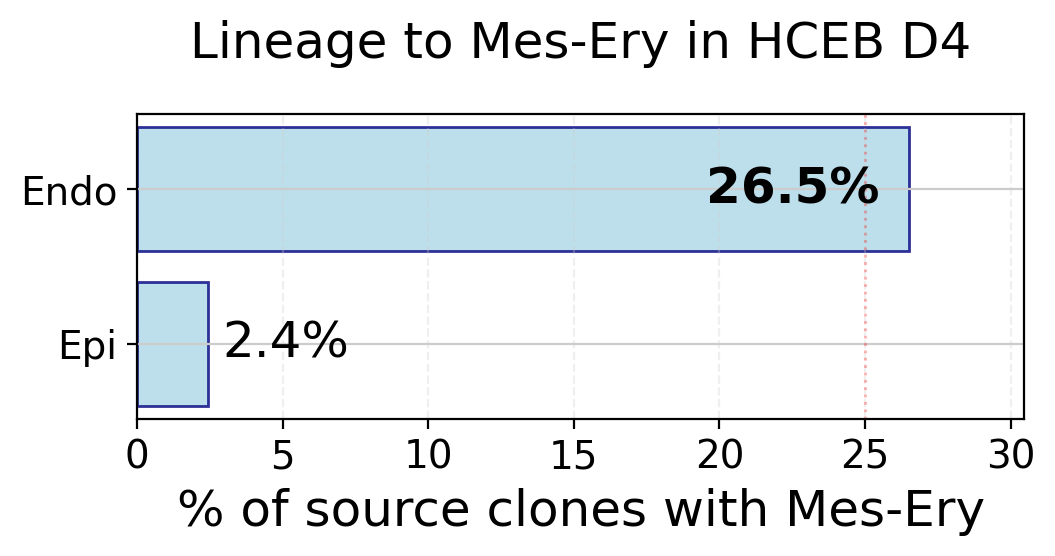

,Source,Target,Source Clones,Target Clones,Shared Clones,Clones with Both,Percentage (shared/source),Ratio (shared/source),Shared Clone IDs,Clones with Both IDs
0,Endo,Mes-Ery,117,303,31,31,26.495726,31/117,"[clone_719, clone_151, clone_1615, clone_423, ...","[clone_719, clone_151, clone_1615, clone_423, ..."
1,Epi,Mes-Ery,1143,303,28,28,2.449694,28/1143,"[clone_595, clone_1066, clone_660, clone_480, ...","[clone_595, clone_1066, clone_660, clone_480, ..."


In [4]:
from src.clonality import quick_clone_check, analyze_multiple_to_B, visualize_sources_to_B, plot_shared_clones_AB_only
visualize_sources_to_B(adata_d4, 'CellType_man', 
                       ['Endo', 'Epi'], 
                       'Mes-Ery', 
                       figsize=(5.5, 3), 
                      fig_title='Lineage to Mes-Ery in HCEB D4')

Recovering clone_type from larry_clone...


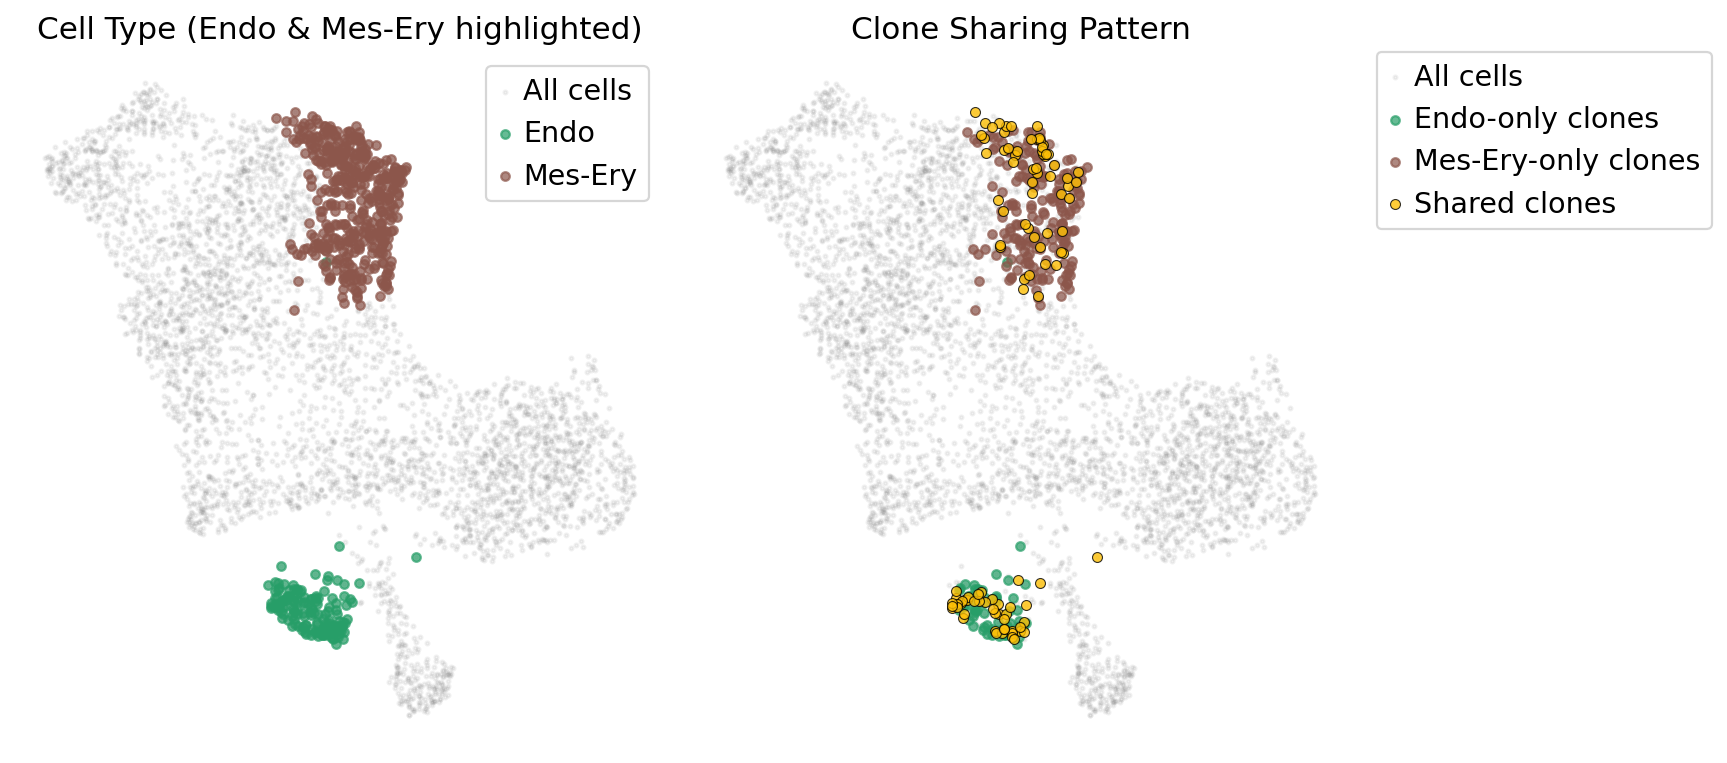

In [9]:
from src.clonality import plot_shared_clones_AB_only
plot_shared_clones_AB_only(adata_d4, 'CellType_man', 'Endo', 'Mes-Ery', 
                               '#279E68', '#8C564B', '#FFC107', )

Recovering clone_type from larry_clone...


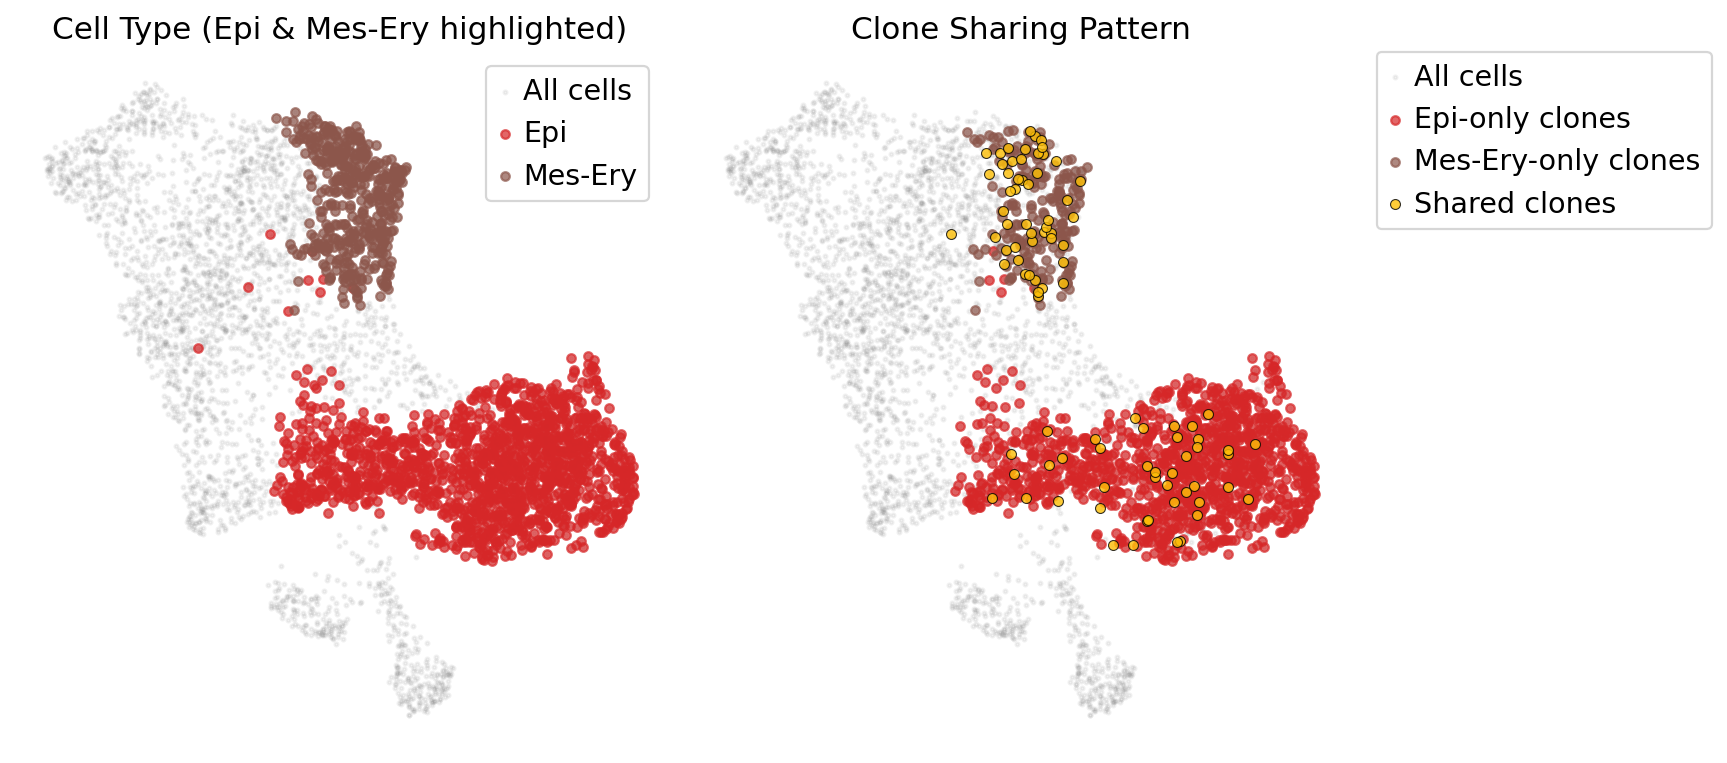

In [13]:
from src.clonality import plot_shared_clones_AB_only
plot_shared_clones_AB_only(adata_d4, 'CellType_man', 'Epi', 'Mes-Ery', 
                               '#D62728', '#8C564B', '#FFC107', )

Recovering clone_type from larry_clone...


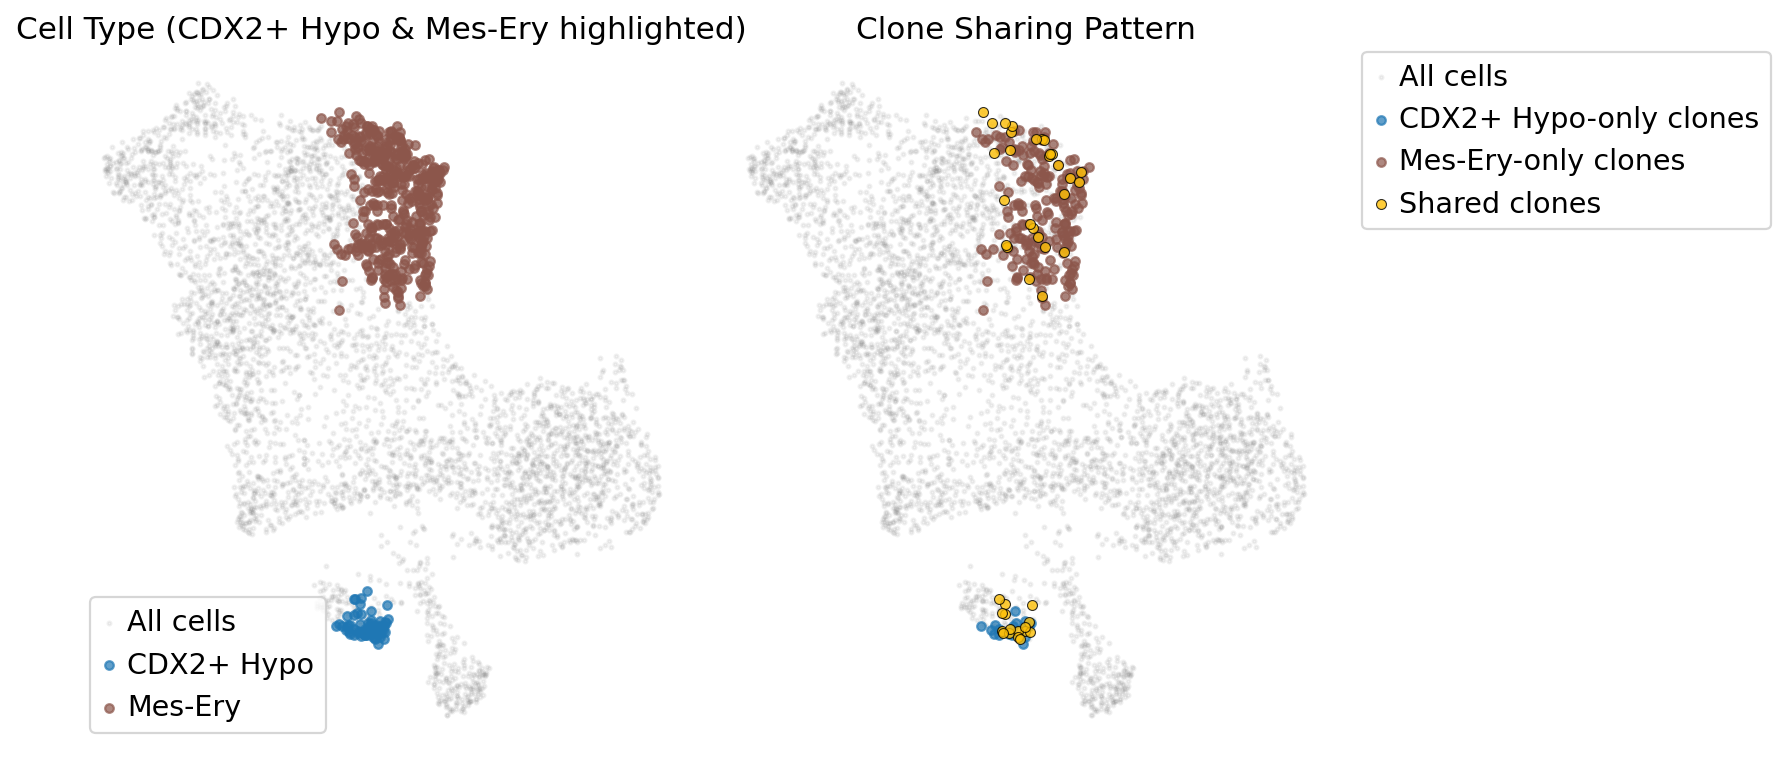

In [12]:
from src.clonality import plot_shared_clones_AB_only
plot_shared_clones_AB_only(adata_d4, 'CellType_man_v2', 'CDX2+ Hypo', 'Mes-Ery', 
                               '#1F77B4', '#8C564B', '#FFC107', )

### Day 7

ANALYSIS: How many clones of different sources go to Mes-Ery?
Target cell type: Mes-Ery (507 clones)
Metric: (shared clones between source and B) / (source clones)

RESULTS (sorted by percentage, highest first):
Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
  Endo             37              2                        5.41                  2/37
   Epi             86              1                        1.16                  1/86

INTERPRETATION:
Higher percentage means more of that source's clones also contain Mes-Ery
Example: 50% means half of that source's clones also go to Mes-Ery

TOP FINDING: Endo has highest sharing with Mes-Ery
  → 5.4% of Endo clones contain Mes-Ery
  → That's 2 out of 37 clones


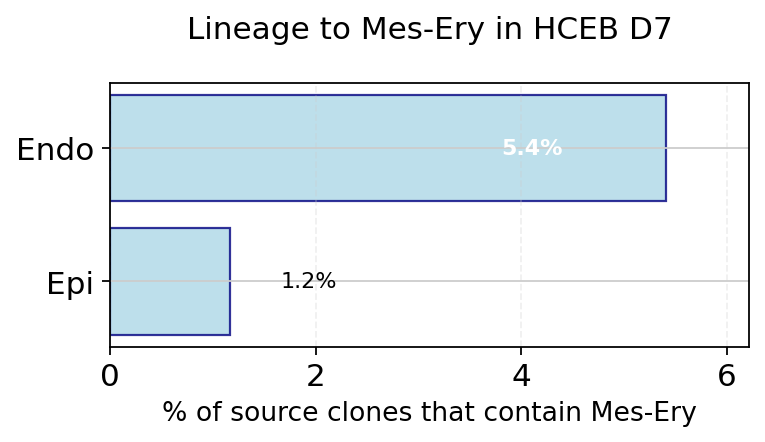

,Source,Target,Source Clones,Target Clones,Shared Clones,Clones with Both,Percentage (shared/source),Ratio (shared/source),Shared Clone IDs,Clones with Both IDs
0,Endo,Mes-Ery,37,507,2,2,5.405405,2/37,"[clone_773, clone_249]","[clone_773, clone_249]"
1,Epi,Mes-Ery,86,507,1,1,1.162791,1/86,[clone_541],[clone_541]


In [7]:
from src.clonality import quick_clone_check, analyze_multiple_to_B, visualize_sources_to_B, plot_shared_clones_AB_only
visualize_sources_to_B(adata_d7, 'celltype_work', 
                       ['Endo', 'Epi'], 
                       'Mes-Ery', 
                       figsize=(5, 3), 
                      fig_title='Lineage to Mes-Ery in HCEB D7')

ANALYSIS: How many clones of different sources go to EMP?
Target cell type: EMP (61 clones)
Metric: (shared clones between source and B) / (source clones)

RESULTS (sorted by percentage, highest first):
 Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
     HE            223             23                       10.31                23/223
Mes-Ery            507              3                        0.59                 3/507

INTERPRETATION:
Higher percentage means more of that source's clones also contain EMP
Example: 50% means half of that source's clones also go to EMP

TOP FINDING: HE has highest sharing with EMP
  → 10.3% of HE clones contain EMP
  → That's 23 out of 223 clones


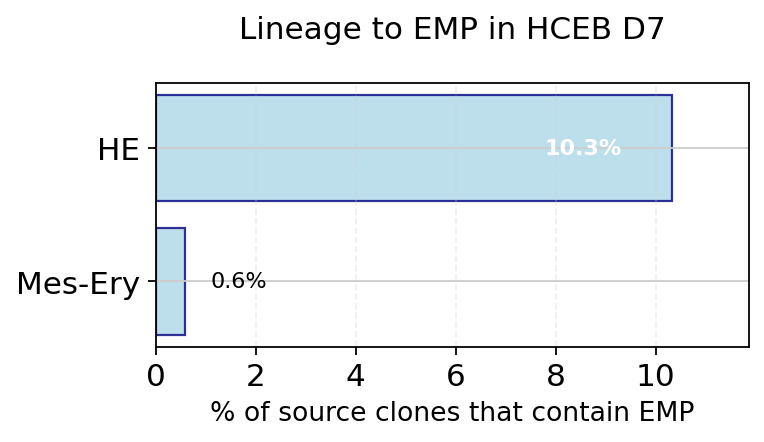

,Source,Target,Source Clones,Target Clones,Shared Clones,Clones with Both,Percentage (shared/source),Ratio (shared/source),Shared Clone IDs,Clones with Both IDs
0,HE,EMP,223,61,23,23,10.313901,23/223,"[clone_266, clone_21, clone_81, clone_173, clo...","[clone_266, clone_21, clone_81, clone_173, clo..."
1,Mes-Ery,EMP,507,61,3,3,0.591716,3/507,"[clone_74, clone_266, clone_862]","[clone_74, clone_266, clone_862]"


In [59]:
from src.clonality import quick_clone_check, analyze_multiple_to_B, visualize_sources_to_B, plot_shared_clones_AB_only
visualize_sources_to_B(adata_d7, 'celltype_work', 
                       ['HE', 'Mes-Ery'], 
                       'EMP', 
                       figsize=(5, 3), 
                      fig_title='Lineage to EMP in HCEB D7')

### Day 12

In [3]:
adata = sc.read_h5ad('/mnt/yiming/nfs_share/hema_wave/hemo-larry-d12-rna-v2.h5ad')

In [4]:
adata_raw = sc.read_10x_h5('/mnt/yiming/nfs_share/larry/Larry-D12/outs/filtered_feature_bc_matrix.h5')

reading /mnt/yiming/nfs_share/larry/Larry-D12/outs/filtered_feature_bc_matrix.h5
 (0:00:02)


/mnt/yiming/nfs_share/anaconda3/envs/scvi-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/mnt/yiming/nfs_share/anaconda3/envs/scvi-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [5]:
adata_raw = adata_raw[adata_raw.obs.index.isin(adata.obs.index)]
adata_raw.obs['CellType_man'] = adata.obs['CellType_man']
adata_raw.obsm['X_emb'] = adata.obsm['X_umap']
adata_raw.uns['data_des'] = 'larry-d12'

df_X_clone = adata.obs[['larry_clone']]
cell_ids = [f'cell_{i+1}' for i in range(len(df_X_clone))]

df_X_clone['Cell_ID'] = cell_ids
df_X_clone.rename(columns={'larry_clone': 'Clone_ID'}, inplace=True)

adata_raw.obs_names = cell_ids
cs.pp.get_X_clone(adata_raw, df_X_clone["Cell_ID"], df_X_clone["Clone_ID"])

/tmp/ipykernel_1227826/35042910.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_raw.obs['CellType_man'] = adata.obs['CellType_man']
/mnt/yiming/nfs_share/anaconda3/envs/scvi-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/mnt/yiming/nfs_share/anaconda3/envs/scvi-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/tmp/ipykernel_1227826/35042910.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

reorder clones


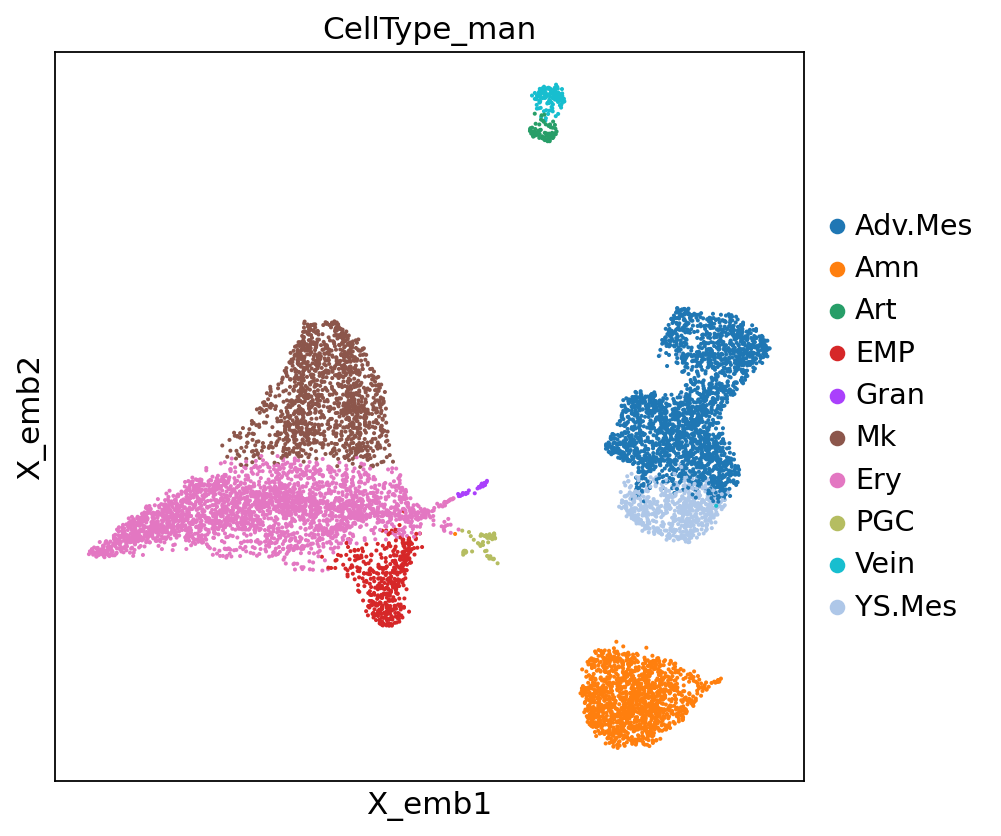

In [6]:
cs.pl.embedding(adata_raw, color="CellType_man")

## preprocessing

normalizing by total count per cell
    finished (0:00:00): normalized adata.X and added
    'n_counts', counts per cell before normalization (adata.obs)
Finding highly variable genes...


/mnt/yiming/nfs_share/anaconda3/envs/scvi-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


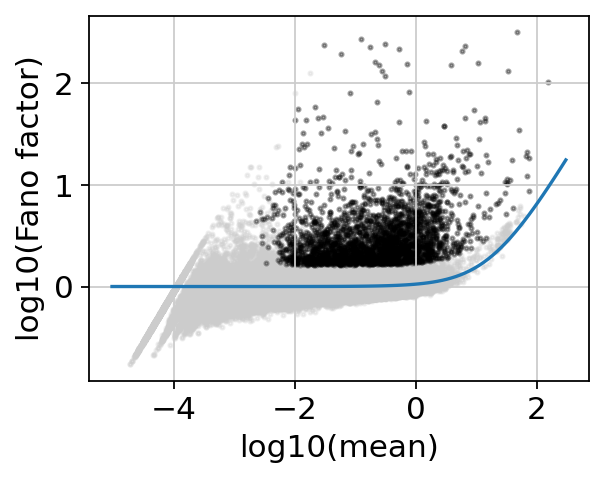

Keeping 2535 genes


In [7]:
cs.pp.get_highly_variable_genes(
    adata_raw,
    normalized_counts_per_cell=10000,
    min_counts=3,
    min_cells=3,
    min_gene_vscore_pctl=90,
)

In [26]:
# cs.pp.remove_cell_cycle_correlated_genes(
#     adata_raw,
#     cycling_gene_list=[
#         'CDK7', 'CDKN1A', 'CDKN1B'
#     ],
# )

In [8]:
adata_raw.var_names_make_unique()

cs.pp.get_X_pca(adata_raw, n_pca_comp=40)
cs.pp.get_X_emb(adata_raw, n_neighbors=20, umap_min_dist=0.3)

/mnt/yiming/nfs_share/anaconda3/envs/scvi-env/lib/python3.9/site-packages/sklearn/utils/validation.py:727: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  warnings.warn(


computing neighbors


/mnt/yiming/nfs_share/anaconda3/envs/scvi-env/lib/python3.9/site-packages/sklearn/utils/validation.py:727: FutureWarning: np.matrix usage is deprecated in 1.0 and will raise a TypeError in 1.2. Please convert to a numpy array with np.asarray. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.matrix.html
  warnings.warn(


    using 'X_pca' with n_pcs = 40


/mnt/yiming/nfs_share/anaconda3/envs/scvi-env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:27)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:11)


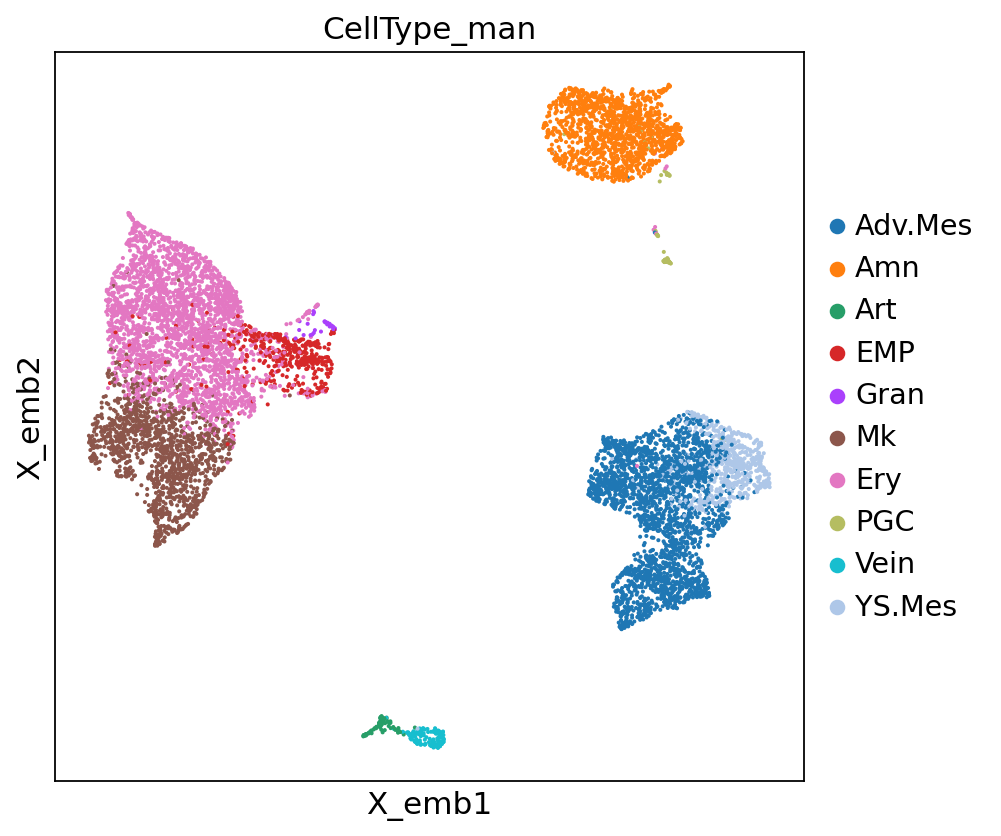

In [9]:
cs.pl.embedding(adata_raw, color="CellType_man")

In [10]:
adata_raw.obs['time_info'] = '12'
adata_raw.obs['state_info'] = adata_raw.obs['CellType_man'].copy()

Data saved at adata.uns['barcode_heatmap']


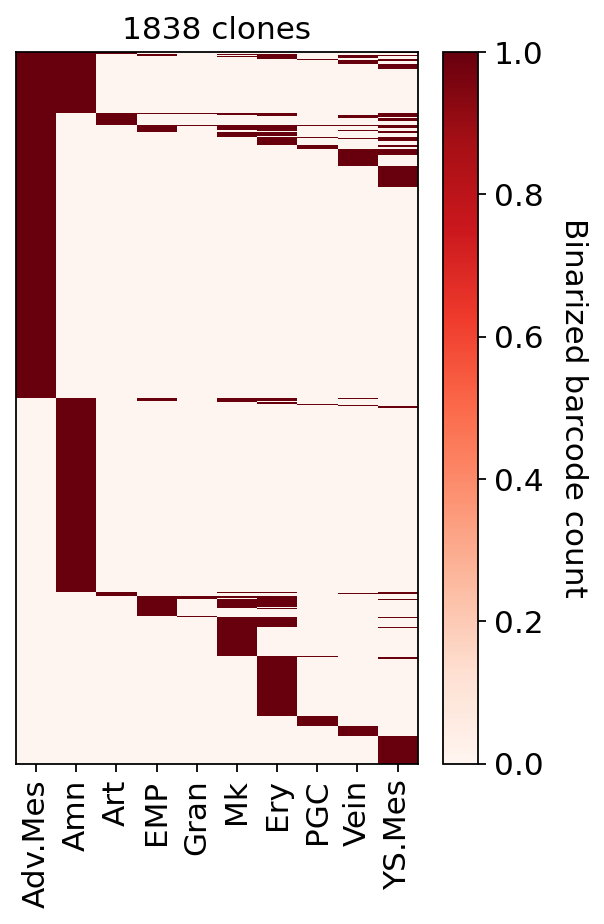

In [11]:
selected_times = None
selected_fates = adata_raw.obs['CellType_man'].cat.categories
celltype_names = adata_raw.obs['CellType_man'].cat.categories
cs.pl.barcode_heatmap(
    adata_raw,
    selected_times=selected_times,
    selected_fates=selected_fates,
    color_bar=True,
    rename_fates=celltype_names,
    log_transform=False,
    binarize=True,
)
ax = plt.gca()
ax.grid(False)

In [12]:
cs.settings.set_figure_params(
    format="png", figsize=[4, 4], dpi=300, fontsize=12, pointsize=3
)

normalize by X_clone
each selected cluster has a unique time point. Normalize per time point
Results saved as dictionary at adata.uns['fate_coupling_X_clone']


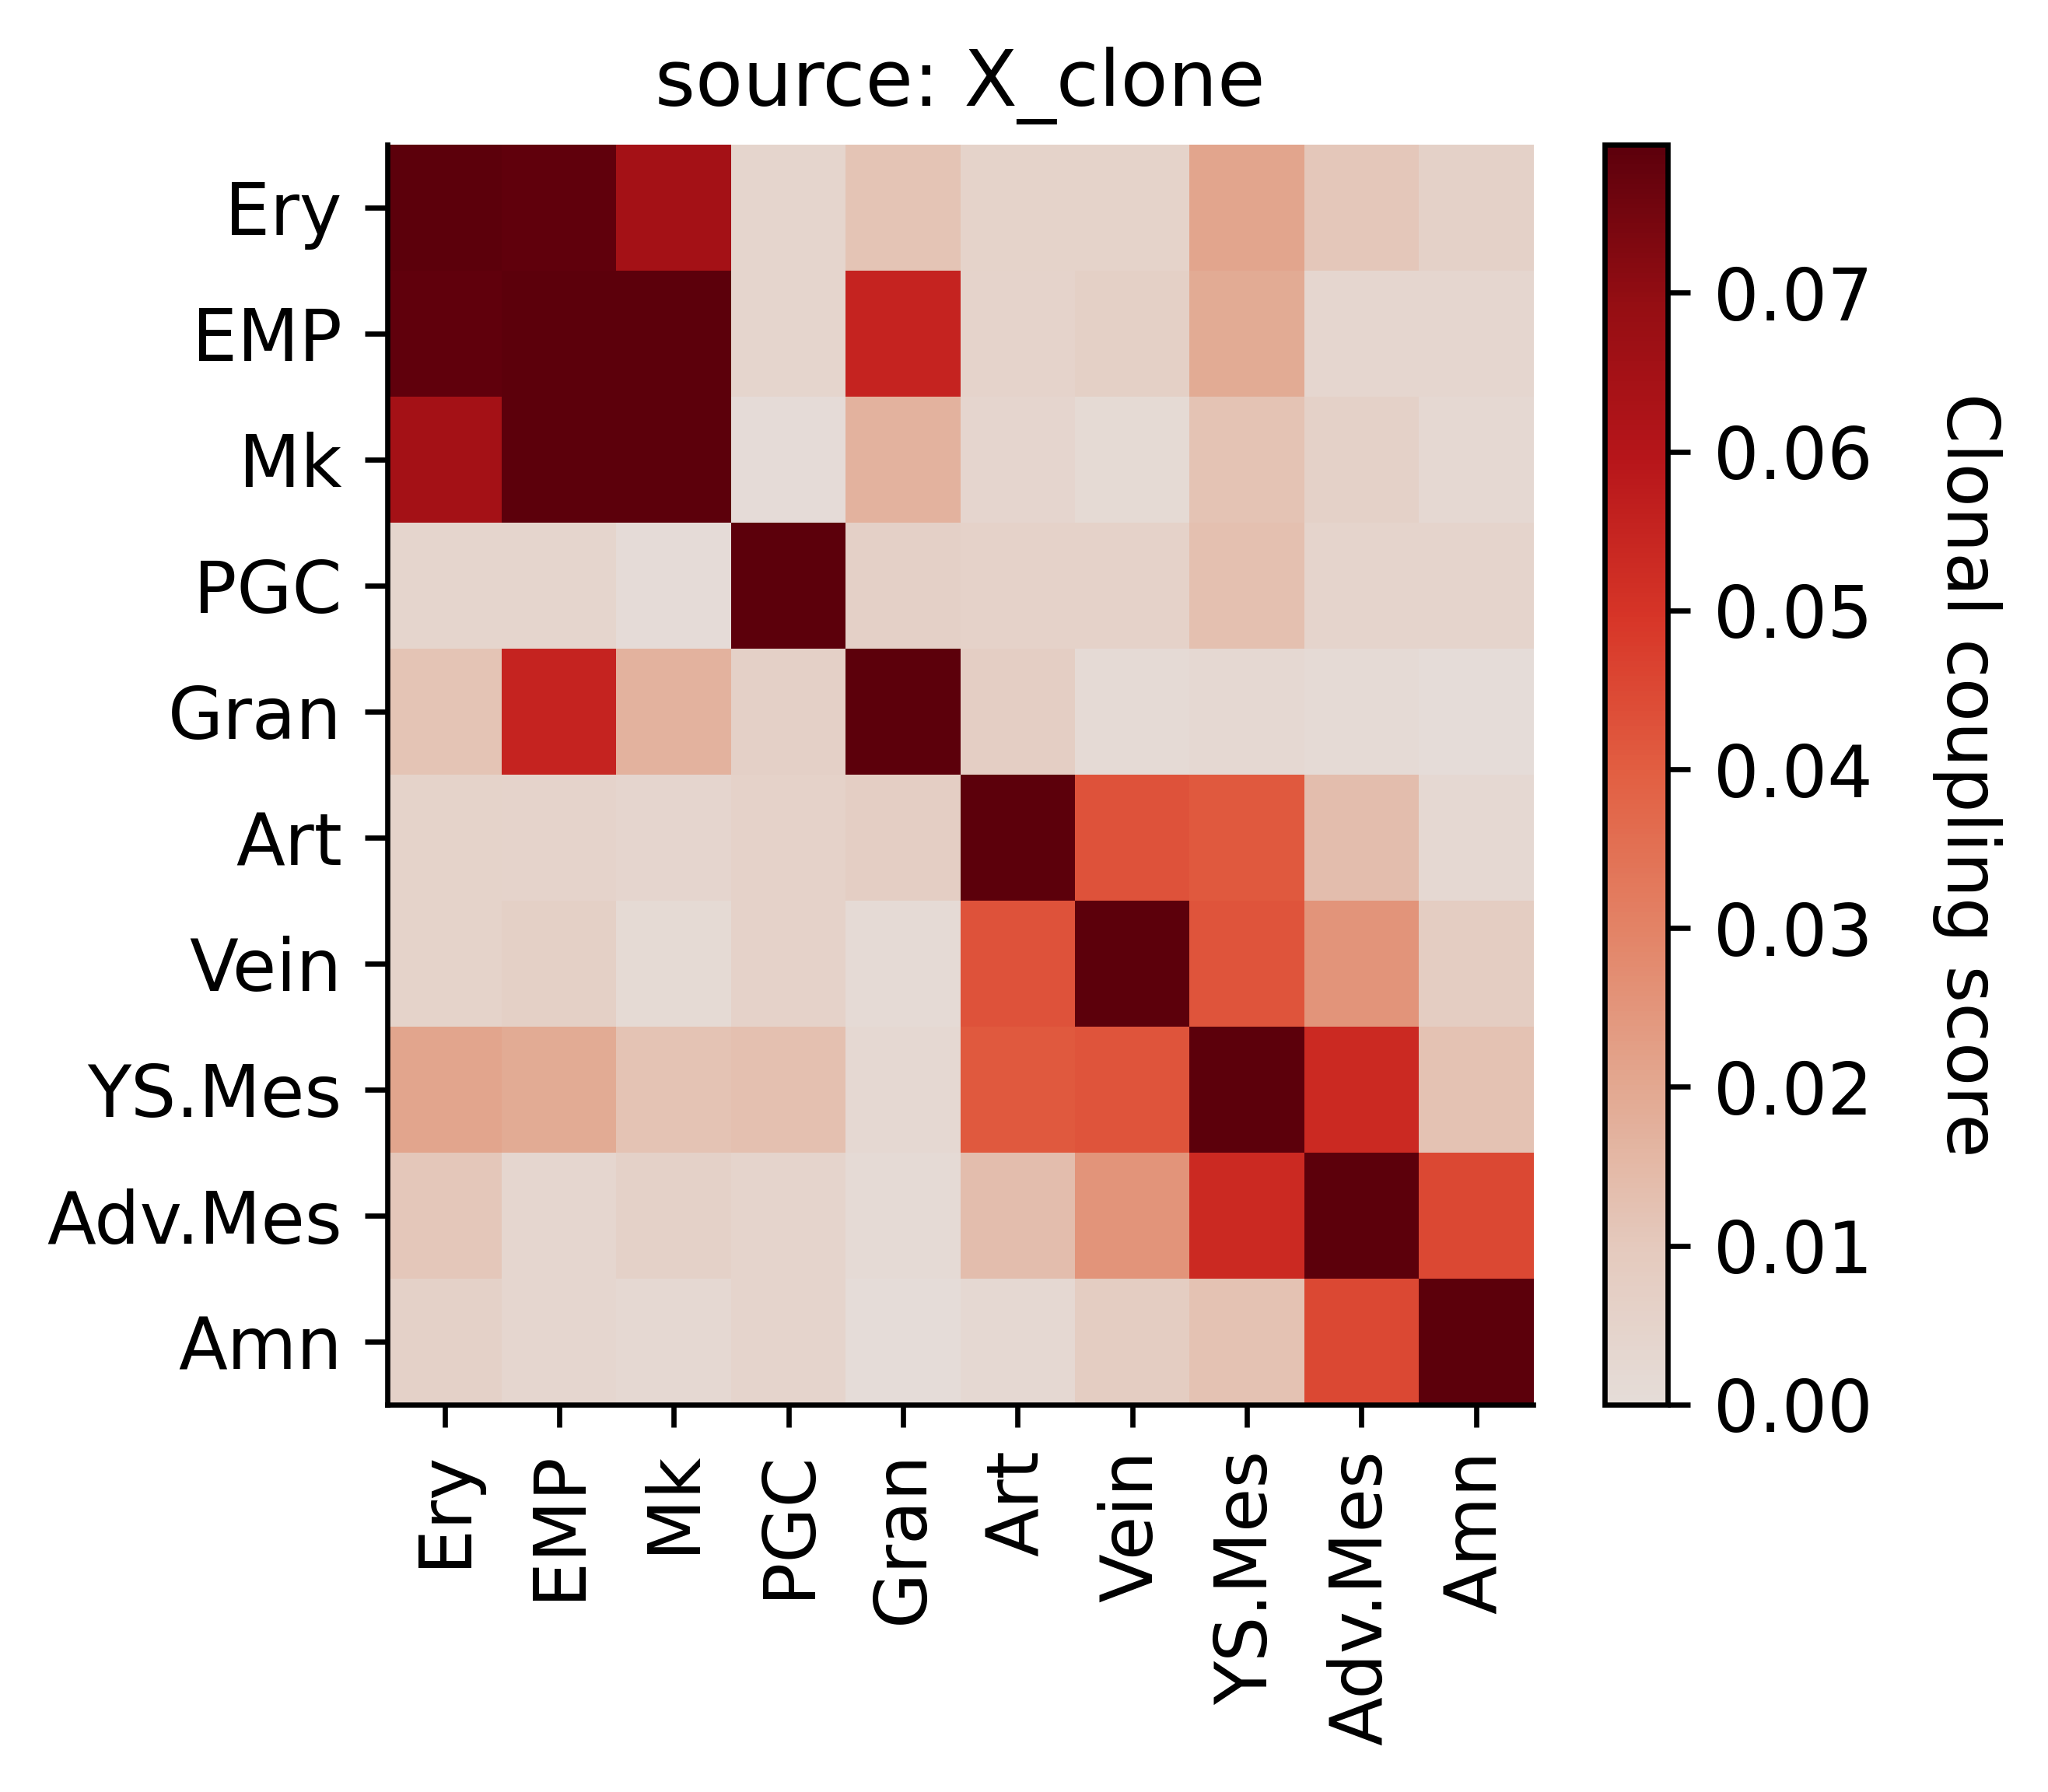

In [13]:
cs.tl.fate_coupling(
    adata_raw, selected_fates=selected_fates, source="X_clone"
)  # compute the fate coupling
cs.pl.fate_coupling(adata_raw, source="X_clone")  # actually plot the coupling
ax = plt.gca()
ax.grid(False)

In [14]:
cs.tl.fate_hierarchy(
    adata_raw, selected_fates=selected_fates, source="X_clone"
)  # compute the fate hierarchy
cs.pl.fate_hierarchy(adata_raw, source="X_clone")  # actually plot the hierarchy

normalize by X_clone
each selected cluster has a unique time point. Normalize per time point
normalize by X_clone
each selected cluster has a unique time point. Normalize per time point
normalize by X_clone
each selected cluster has a unique time point. Normalize per time point
normalize by X_clone
each selected cluster has a unique time point. Normalize per time point
normalize by X_clone
each selected cluster has a unique time point. Normalize per time point
normalize by X_clone
each selected cluster has a unique time point. Normalize per time point
normalize by X_clone
each selected cluster has a unique time point. Normalize per time point
normalize by X_clone
each selected cluster has a unique time point. Normalize per time point
Results saved as dictionary at adata.uns['fate_hierarchy_X_clone']

      /-PGC
   /-|
  |   \-Gran
  |
  |         /-Vein
  |      /-|
--|     |   \-Art
  |   /-|
  |  |  |      /-YS.Mes
  |  |  |   /-|
  |  |   \-|   \-Adv.Mes
   \-|     |
     |      \-

ANALYSIS: How many clones of different sources go to Ery?
Target cell type: Ery (293 clones)
Metric: (shared clones between source and B) / (source clones)

RESULTS (sorted by percentage, highest first):
Source  Source Clones  Shared Clones  Percentage (shared/source) Ratio (shared/source)
   EMP             86             64                       74.42                 64/86
YS.Mes            240             46                       19.17                46/240

INTERPRETATION:
Higher percentage means more of that source's clones also contain Ery
Example: 50% means half of that source's clones also go to Ery

TOP FINDING: EMP has highest sharing with Ery
  → 74.4% of EMP clones contain Ery
  → That's 64 out of 86 clones


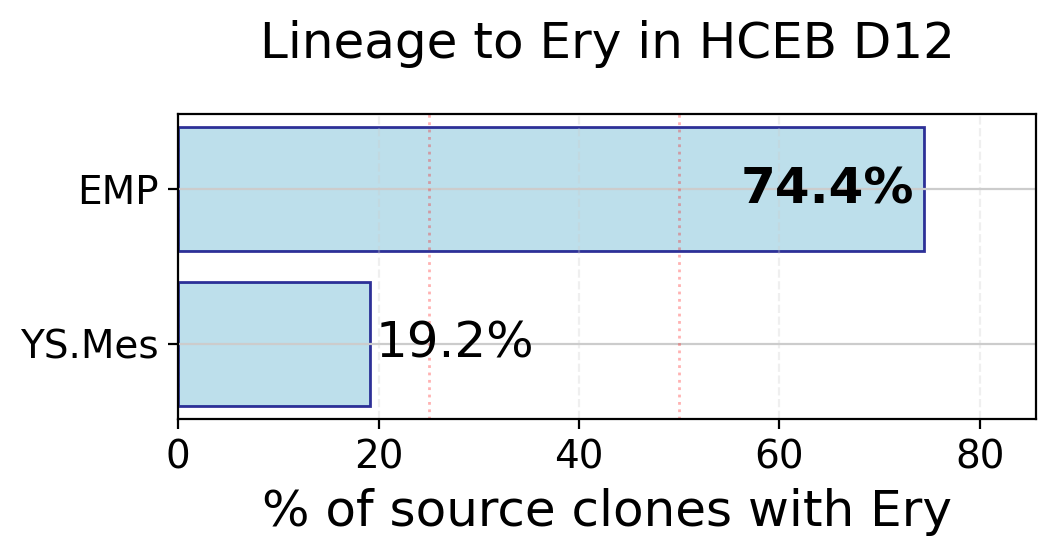

,Source,Target,Source Clones,Target Clones,Shared Clones,Clones with Both,Percentage (shared/source),Ratio (shared/source),Shared Clone IDs,Clones with Both IDs
1,EMP,Ery,86,293,64,64,74.418605,64/86,"[clone_1099, clone_153, clone_277, clone_78, c...","[clone_1099, clone_153, clone_277, clone_78, c..."
0,YS.Mes,Ery,240,293,46,46,19.166667,46/240,"[clone_165, clone_172, clone_5, clone_323, clo...","[clone_165, clone_172, clone_5, clone_323, clo..."


In [3]:
from src.clonality import quick_clone_check, analyze_multiple_to_B, visualize_sources_to_B, plot_shared_clones_AB_only
visualize_sources_to_B(adata_d12, 'celltype_work', 
                       ['YS.Mes', 'EMP'], 
                       'Ery', 
                       figsize=(5.5, 3), 
                      fig_title='Lineage to Ery in HCEB D12')

Recovering clone_type from larry_clone...


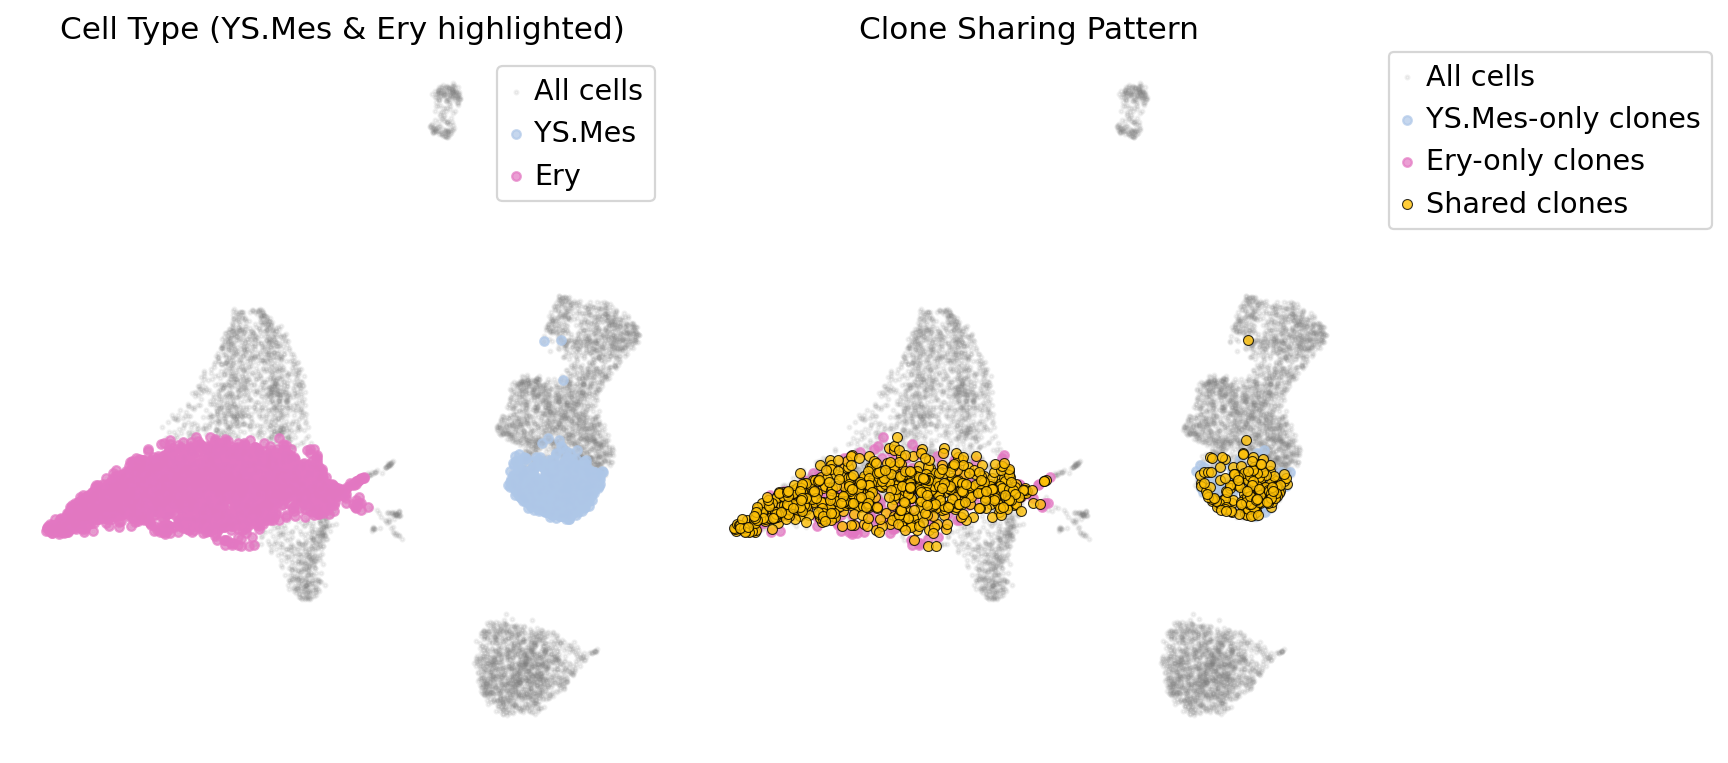

In [6]:
from src.clonality import plot_shared_clones_AB_only
plot_shared_clones_AB_only(adata_d12, 'celltype_work', 'YS.Mes', 'Ery', 
                               '#AEC7E8', '#E377C2', '#FFC107', )